#**CLASSIFICATION PNEUMONIE VIA TRANSFER LEARNING**

In [1]:
# installation des librairies nécessaires

!pip install keras==3.12.0
!pip install tensorflow==2.20.0
!pip install kagglehub
!pip install scikit-learn

print("INSTALLATION TERMINÉE")
print(f"version de tensorflow : {tensorflow.__version__}")
print(f"version de keras : {keras.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 105.4 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is in

In [12]:
# import des librairies

import kagglehub
import seaborn as sns
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import keras
from google.colab import drive
import sys
import tensorflow
from keras.preprocessing import image_dataset_from_directory
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.models import Model, load_model
from keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from keras.optimizers import Adam
from keras.metrics import BinaryAccuracy, Recall, Precision, AUC
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

import os

# 1. On force Colab à utiliser l'ancienne version de Keras (Keras 2)
# Cela doit être fait AVANT d'importer tensorflow !
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import keras

print(f"Version TensorFlow : {tf.__version__}")
# Tu devrais voir une version qui finit par .keras2 ou un message indiquant le mode legacy
print("Importations terminées")

# constante
BATCH_SIZE = 32
IMG_SIZE = (224,224)

Version TensorFlow : 2.20.0
Importations terminées


Maintenant que les toutes les librairies sont installées et ont bien été importées, il est temps d'importer le jeu de données. Ce-dernier est récupéré sur Kaggle : https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
Il est composé de 3 dossiers (train, test et val) dans lesquels il y a pour chacuns d'eux 2 sous-dossiers (NORMAL et PNEUMONIA) contenant les radios thoraciques de patients ayant des poumons malades (pneumonie) ou des poumons sains.

In [3]:
# téléchargement des données venant de Kaggle
# à savoir qu'au téléchargement, les trois dossiers se trouvent dans un dossier "chest_xray" que l'on doit indiquer

chemin_telechargement = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print(f"chemin du jeu de données : {chemin_telechargement}")

dossier_base = os.path.join(chemin_telechargement, "chest_xray")

chemin_train = os.path.join(dossier_base, "train")
chemin_test = os.path.join(dossier_base, "test")

100%|██████████| 2.29G/2.29G [00:25<00:00, 95.4MB/s]

Extracting files...


chemin du jeu de données : /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


Maintenant que le jeu de données est importer dans notre dossier Google Colab, nous allons utiliser la fonction "image_dataset_from_directory()" pour indiquer dans quel sous-dossier keras est sensé construire le jeu d'entraînement, de test et d'évaluation.

In [4]:
train_set = image_dataset_from_directory(
    directory=chemin_train,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.2,
    seed=123,
    subset="training"
)
val_set = image_dataset_from_directory(
    directory=chemin_train,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.2,
    seed=123,
    subset="validation"
)
test_set = image_dataset_from_directory(
    directory=chemin_test,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.


Nous remarquons que notre dossier jeu d'entraînement contient 5 216 images tandis que le jeu de test en contient 624.

Nous allons à présent commencer la création du modèle. Le but de cet exercice est d'importer un modèle pré-entraîner sur un large volume de données (ici le modèle VGG16 entraîner sur la banque d'image "imagenet"), de freeze ce modèle pour créer le notre qui ne reconnaisse que les pneumonies et les cas sains et ainsi gagner en temps d'entraînement.


In [5]:
inputs = Input(shape=(224,224,3))
x = preprocess_input(inputs) # transforme l'input pour que VGG comprenne

baseModel = VGG16(include_top=False, weights="imagenet", input_tensor=x)
baseModel.trainable = False # on gèle les poids du modèle VGG16
x = baseModel.output # sortie du modèle de base
x = GlobalAveragePooling2D()(x)
x = Dense(units=128, activation="relu")(x)
x = Dropout(rate=0.2)(x) # on éteint 20% des neuronnes au hasard à chaque tour
outputs = Dense(units=1, activation="sigmoid")(x) # binaire car Pneumonie ou Normale

model = Model(inputs=inputs, outputs=outputs)

Nous pouvons voir que nous avons rajouté au modèle VGG16

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        BinaryAccuracy(name="accuracy"),
        Recall(name="recall"), # ne pas rater les malades IMPORTANT
        Precision(name="precision"),
        AUC(name="auc") # aire sous la courbe qui mesure la performance globale
    ]
)

Il y a dans le jeu de donnée, beaucoup plus de cas de pneumonie que de cas noramux. Il faut donc durant l'entraînement que le modèle calcule ses pieds en fonction du nombre de cas pour obtenir un learning rate plus important quand il tombe sur un cas sain. Ainsi dans notre calcul, une erreur du modèle sur un cas sain "compte triple".
Voici une formule commune pour équilibrer les poids d'un modèle en fonction du nombre de cas : poids = (1 / nombreClasses) * (total / 2)

In [7]:
nombre_normal = len(os.listdir(os.path.join(chemin_train, "NORMAL")))
nombre_pneumonie = len(os.listdir(os.path.join(chemin_train, "PNEUMONIA")))

total = nombre_normal + nombre_pneumonie

weightFor1 = (1 / nombre_pneumonie) * (total / 2) # pneumonie
weightFor0 = (1 / nombre_normal) * (total / 2) # normal
class_weight = {0: weightFor0, 1: weightFor1} # dictionnaire pour classer les poids

print(f"Poids Classe 0 (Normal)   : {weightFor0:.2f}")
print(f"Poids Classe 1 (Pneumonie): {weightFor1:.2f}")

Poids Classe 0 (Normal)   : 1.94
Poids Classe 1 (Pneumonie): 0.67


Nous créons avant l'entraînement de notre modèle une fonction "callback()" qui va permettre d'arrêter l'entraînement du modèle si la fonction de perte augmente depuis 3 epochs ("earlyStopping") ainsi qu'une fonction "checkPoint()" permettant de sauvegarder la meilleure version du modèle (ayant la perte la plus basse sur le jeu de validation "val_set")

In [8]:
earlyStopping = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
# arrête la "val_loss" si le modèle n'apprend plus depuis 3 epochs

checkPoint = ModelCheckpoint(
    filepath="modelVGG16ClassificationPneumonie.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

Pour des raisons de temps et de complications, nous n'allons pas entraîner le modèle dans Google Colab (environ une heure d'entraînement) mais je vous laisse le soin de dé-commenter les lignes ci-dessous pour l'entraînement vous-même.

Nous allons donc importer le modèle final déjà entraîner dans Google Colab.

In [9]:
# print("ENTRAÎNEMENT")
# history = model.fit(
#     train_set,
#     validation_data=val_set,
#     epochs=10,
#     class_weight=class_weight,
#     callbacks=[earlyStopping, checkPoint]
# )

print("chargement du meilleur modele sauvegardé par la fonction ModelCheckpoint()")

drive.mount("/content/drive") # connecte le Google Drive à Colab
chemin_modele = "/content/drive/MyDrive/deepLearning/classificationPneumonies/modelVGG16ClassificationPneumonie.keras"

print("Chargement du modèle dans Google Colab")
modelCharge = load_model(chemin_modele)

print("Modèle chargé")

modelCharge.summary()

chargement du meilleur modele sauvegardé par la fonction ModelCheckpoint()
Mounted at /content/drive
Chargement du modèle dans Google Colab
Modèle chargé


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_15         │ (None, 224, 224)  │          0 │ input_layer_5[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_16         │ (None, 224, 224)  │          0 │ input_layer_5[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_17         │ (None, 224, 224)  │          0 │ input_layer_5[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_5 (Stack)     │ (None, 224, 224,  │          0 │ get_item_15[0][0… │
│                     │ 3)                │            │ get_item_16[0][0… │
│                     │                   │            │ get_item_17[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 224, 224,  │          0 │ stack_5[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ add_5[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 14,912,069 (56.89 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 131,588 (514.02 KB)

Maintenant que le modèle entraîné est chargé, nous allons l'évaluer sur un jeu de test "test_set".

In [10]:
y_true = []; y_pred_proba = []
for images, labels in test_set:
    y_true.extend(labels.numpy()) # sauvegarde des vrais réponses

    preds = modelCharge.predict(images, verbose=0)
    y_pred_proba.extend(preds)

y_true = np.array(y_true)
y_pred_proba = np.array(y_pred_proba)

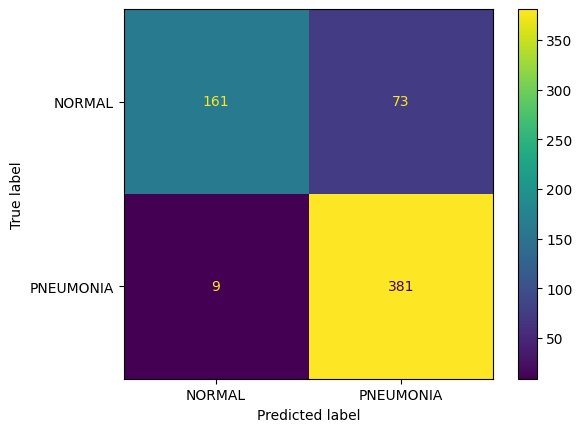

In [11]:
y_pred = (y_pred_proba > 0.6).astype(int)

cm = confusion_matrix(y_true=y_true, y_pred=y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=test_set.class_names)
cmd.plot()
plt.show()

Avec la matrice de confusion ci-dessus nous pouvons analyser les performances de notre modèle dans ce cas très sensible de classification de pneumonies. Pendant toute la recherche du meilleur seuil de probabilité (à partir duquel notre modèle classe ou non en tant que malade ou pas la radio), il est important de garder en tête que nous voulons un minimum de FAUX NÉGATIFS, soit des malades interprété comme étant sains. C'est à dire des personnes ayant une pneumonie mais qui seront renvoyé chez eux sans soins car pris pour des personnes saines.
À l'aide de notre matrice, nous constatons qu'il y a 9 FAUX NÉGATIFS, ie des personnes malades prédits comme saines et 73 FAUX POSITIFS càd des personnes sainses prédites comme étant malades.

In [17]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Attention piège de l'AUC : Elle a besoin des probabilités, pas des 0 et des 1 !
auc = roc_auc_score(y_true, y_pred_proba)

# 3. Création du tableau de présentation avec Pandas
resultats_df = pd.DataFrame({
    "Métrique": ["Accuracy",
                 "Précision",
                 "Rappel",
                 "F1-Score ",
                 "AUC"],
    "Score": [acc, prec, rec, f1, auc]
})

display(resultats_df.style.format({"Score": "{:.2%}"}))

,Métrique,Score
0,Accuracy,86.86%
1,Précision,83.92%
2,Rappel,97.69%
3,F1-Score,90.28%
4,AUC,95.38%


Nous avons désormais étudier avec l'aide de la librairie ```metrics``` de ```scikit-learn``` les différentes métriques liées à notre modèle sur le jeu de test.

Ainsi, comme dit précédemment, le point sur lequel nous devons être particulièrement exigent est le rappel, qui est la proportion de vrais positifs par rapport à tous les malades dans le jeu de données. Soit la proportion de cas positifs trouvé (et qui sont réels) sur tout les positifs. Ici, il est excellent puisque nous avoisinons les 98%.